# Library Importation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

# Data importation

In [2]:
raw = pd.read_excel('/content/Final Chitosan_Turbidity_ML_Dataset.xlsx', header=None)
df = raw.iloc[2:].copy()
df.columns = ['Run', 'Design', 'DDA', 'MW', 'Dose', 'pH',
               'Settling_Time', 'Initial_Turb', 'Rapid_Mix',
               'Residual_Turb', 'Turbidity_Removal']
df = df.drop(columns=['Run', 'Design'])
df = df.apply(pd.to_numeric, errors='coerce')
df = df.dropna()
df = df[df['Turbidity_Removal'] > 0].reset_index(drop=True)
df.head(10)


,DDA,MW,Dose,pH,Settling_Time,Initial_Turb,Rapid_Mix,Residual_Turb,Turbidity_Removal
0,85.2,250.0,5.0,5.00,15,80.0,200,30.1,62.4
1,85.2,250.0,5.0,6.50,30,80.0,200,22.6,71.8
2,85.2,250.0,5.0,8.00,45,80.0,200,35.7,55.3
3,85.2,250.0,15.0,5.00,45,80.0,200,21.2,73.5
4,85.2,250.0,15.0,6.50,30,80.0,200,14.3,82.1
5,85.2,250.0,15.0,6.50,30,80.0,200,14.7,81.6
6,85.2,250.0,15.0,6.50,30,80.0,200,13.7,82.9
7,85.2,250.0,15.0,8.00,15,80.0,200,28.2,64.7
8,85.2,250.0,20.0,5.00,30,80.0,200,16.6,79.2
9,85.2,250.0,20.0,6.25,30,80.0,200,9.8,87.7


# Data Exploration 1(Statistical DEA)

In [3]:
print("Shape:", df.shape)

Shape: (62, 9)


In [4]:
df.describe()

,DDA,MW,Dose,pH,Settling_Time,Initial_Turb,Rapid_Mix,Residual_Turb,Turbidity_Removal
count,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000
mean,82.756452,622.274194,21.782258,7.000806,33.338710,147.096774,171.774194,40.930645,69.483548
std,7.563905,728.933984,30.432756,1.122515,15.240093,142.916450,30.529437,42.416211,24.352738
min,62.200000,50.000000,0.500000,4.000000,10.000000,20.000000,125.000000,2.300000,5.840000
25%,80.000000,273.600000,4.000000,7.000000,23.000000,88.000000,150.000000,13.800000,62.975000
50%,85.200000,400.000000,11.000000,7.000000,30.000000,100.000000,200.000000,24.750000,78.800000
75%,87.300000,800.000000,20.000000,7.575000,30.000000,102.800000,200.000000,58.875000,85.175000
max,92.400000,3200.000000,140.000000,10.000000,60.000000,520.000000,200.000000,201.300000,96.600000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   DDA                62 non-null     float64
 1   MW                 62 non-null     float64
 2   Dose               62 non-null     float64
 3   pH                 62 non-null     float64
 4   Settling_Time      62 non-null     int64  
 5   Initial_Turb       62 non-null     float64
 6   Rapid_Mix          62 non-null     int64  
 7   Residual_Turb      62 non-null     float64
 8   Turbidity_Removal  62 non-null     float64
dtypes: float64(7), int64(2)
memory usage: 4.5 KB


# Data Exploration 2 (Data visualisation - Graphical DEA)

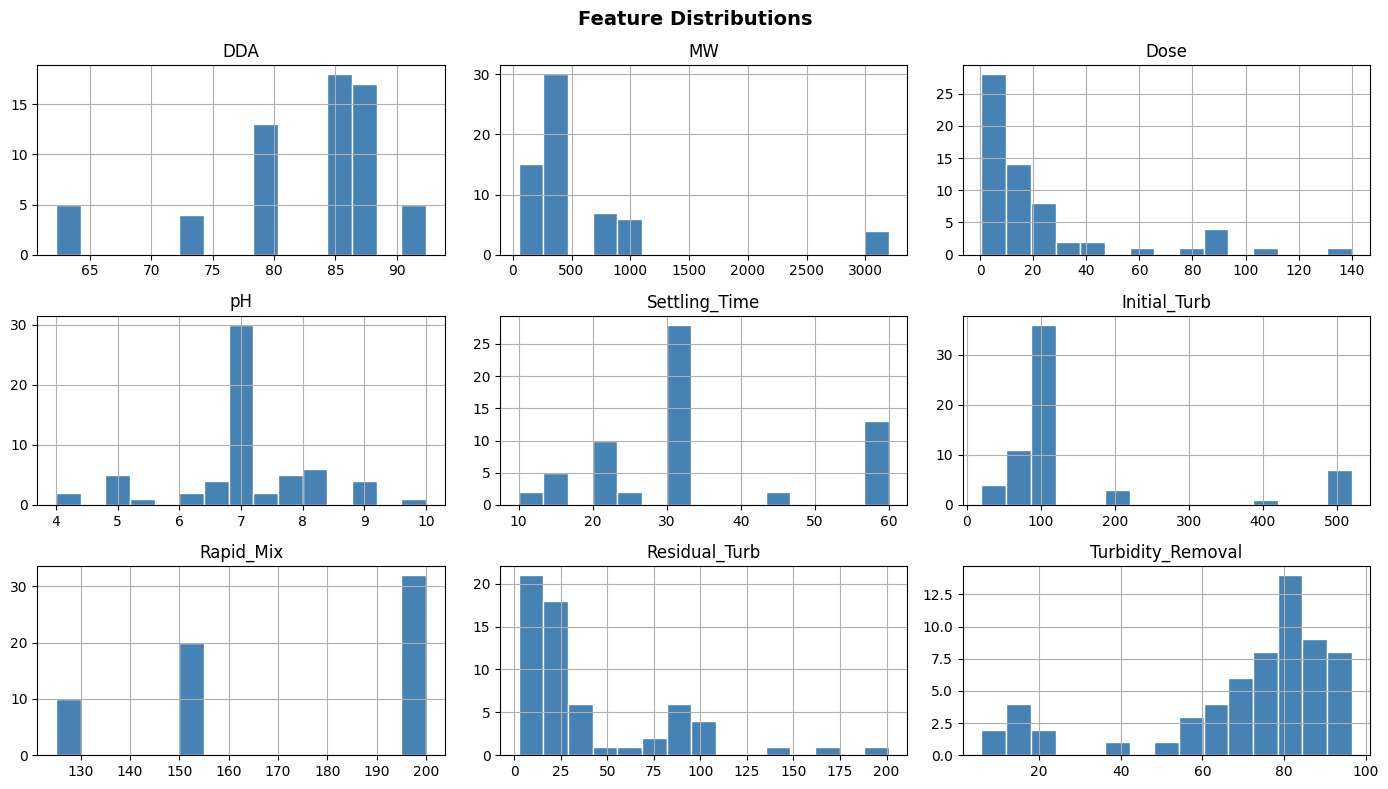

In [6]:
# Distribution plots
df.hist(figsize=(14, 8), bins=15, color='steelblue', edgecolor='white')
plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

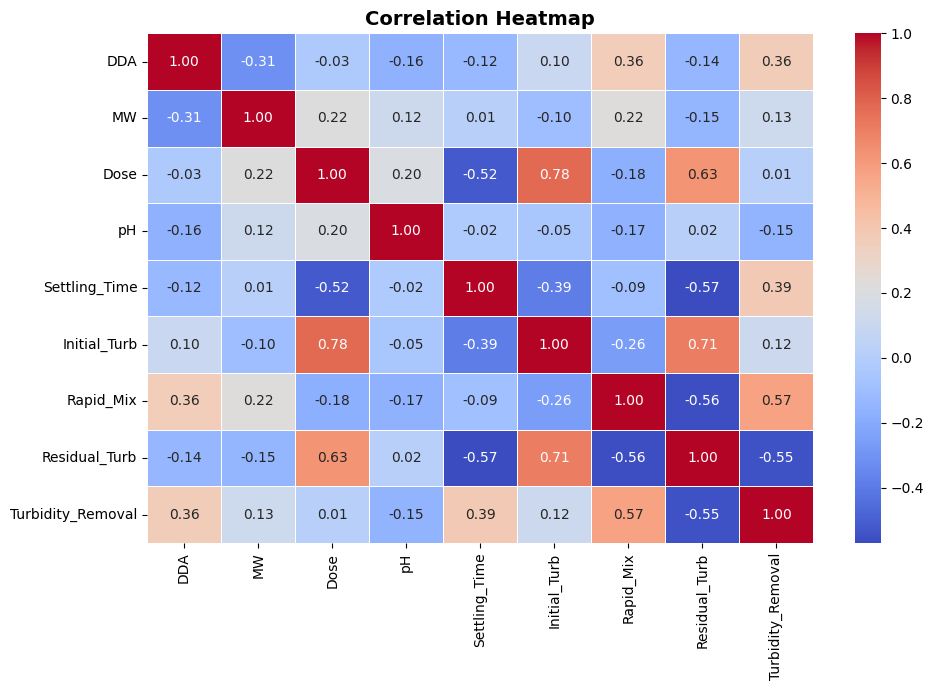

In [7]:
# Correlation heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

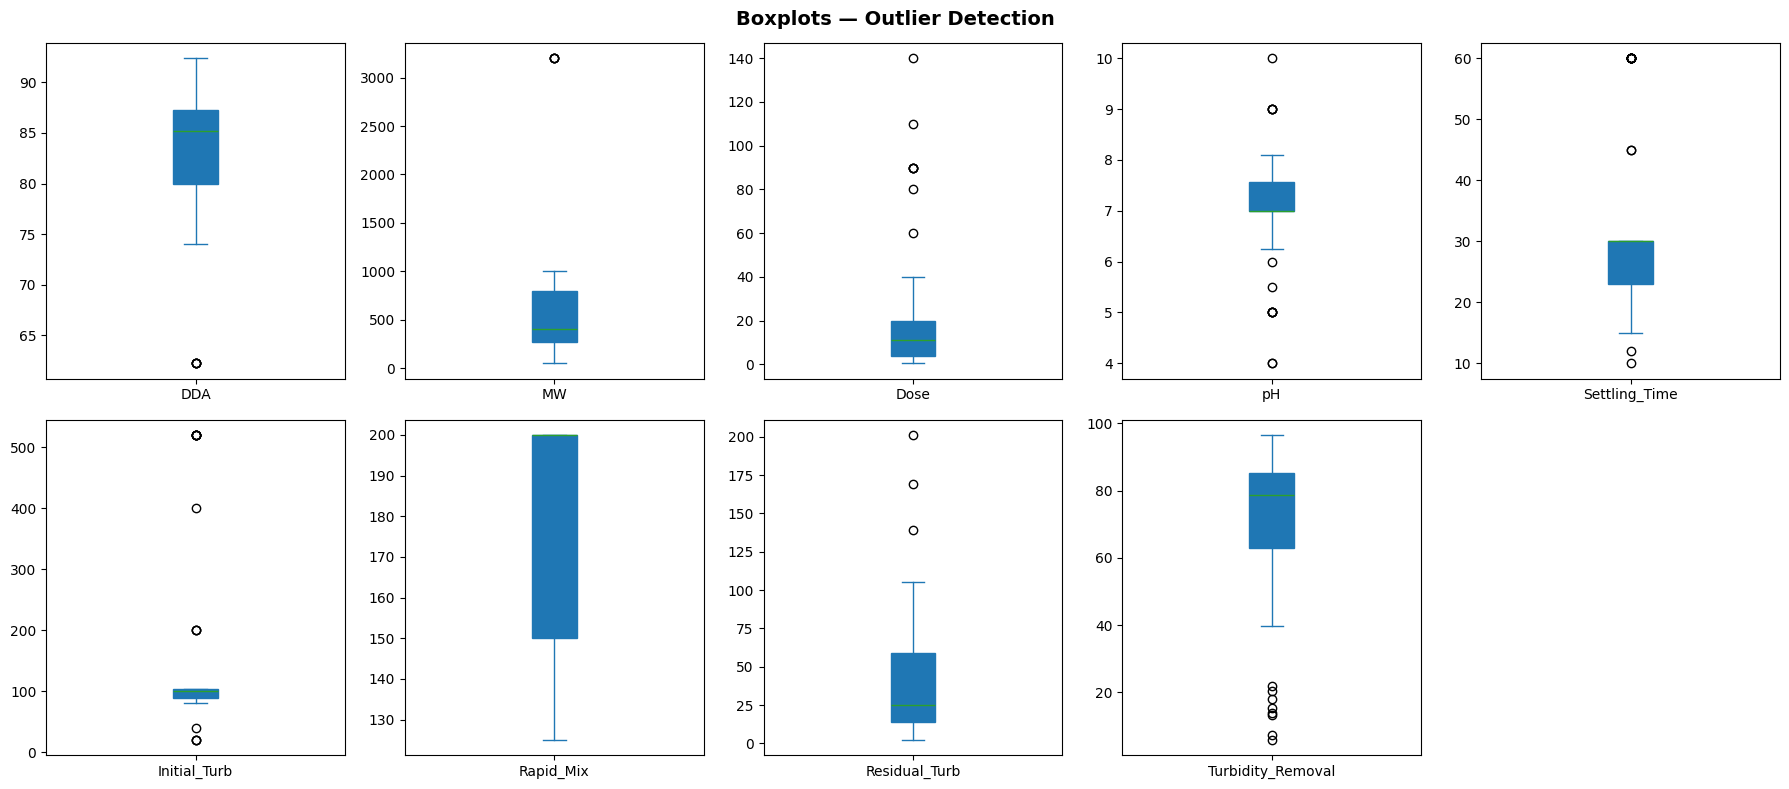

In [8]:
# Boxplots
df.plot(kind='box', subplots=True, layout=(2, 5), figsize=(18, 8),patch_artist=True)
plt.suptitle('Boxplots — Outlier Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# Data splitting 1

In [9]:
features = ['DDA', 'MW', 'Dose', 'pH', 'Settling_Time', 'Initial_Turb','Residual_Turb', 'Rapid_Mix']
target   = 'Turbidity_Removal'
X = df[features]
y = df[target]

# Data splitting 2

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Data preprocessing (standardisation)

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Model development

In [12]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
lr_ped=np.round(lr_pred,2)


In [13]:
# Decision Tree
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_pred=np.round(dt_pred,2)

In [14]:
# Random Forest
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_pred=np.round(rf_pred,2)

In [ ]:
# Support Vector Regression
svr = SVR()
svr.fit(X_train_scaled, y_train)
svr_pred = svr.predict(X_test_scaled)
svr_pred=np.round(svr_pred,2)

# Model evaluation

In [16]:
model_names = ['Linear Regression', 'Decision Tree', 'Random Forest', 'SVR']
predictions = [lr_pred, dt_pred, rf_pred, svr_pred]
results = []
for name, pred in zip(model_names, predictions):
    r2   = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae  = mean_absolute_error(y_test, pred)
    results.append({'Model': name, 'R2': r2, 'RMSE': rmse, 'MAE': mae})

results_df = pd.DataFrame(results)
print(results_df)

               Model        R2       RMSE       MAE
0  Linear Regression  0.935453   7.308536  6.164239
1      Decision Tree  0.970656   4.927829  3.736154
2      Random Forest  0.970245   4.962189  4.095385
3                SVR  0.789868  13.186796  8.913077


In [23]:
dt_pred

array([82.4 , 20.43, 64.7 , 13.23, 82.1 , 79.8 , 95.  , 88.6 , 68.4 ,
       13.23, 68.4 , 82.9 , 79.8 ])

In [18]:
import pickle
with open("model.pkl", "wb") as file:
    pickle.dump(dt, file)
print("Model saved successfully.")

Model saved successfully.


# Performances of each developed model

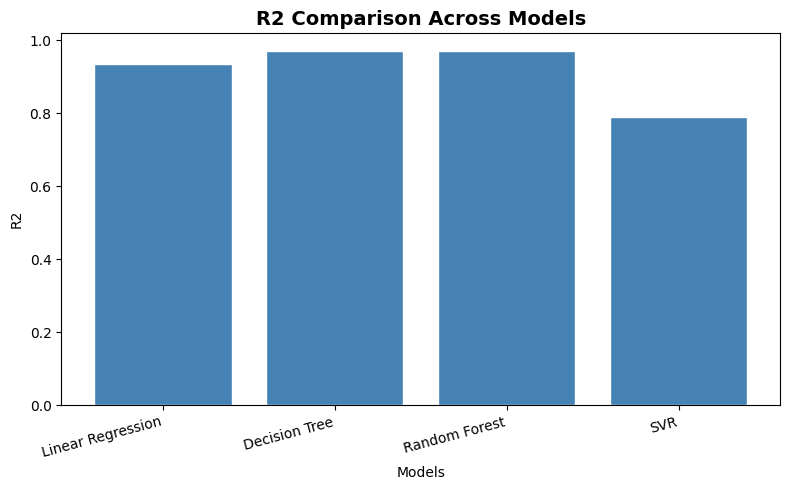

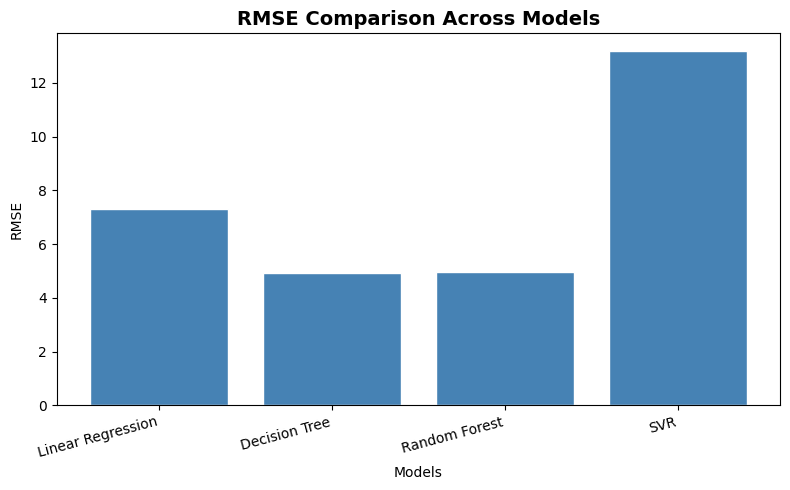

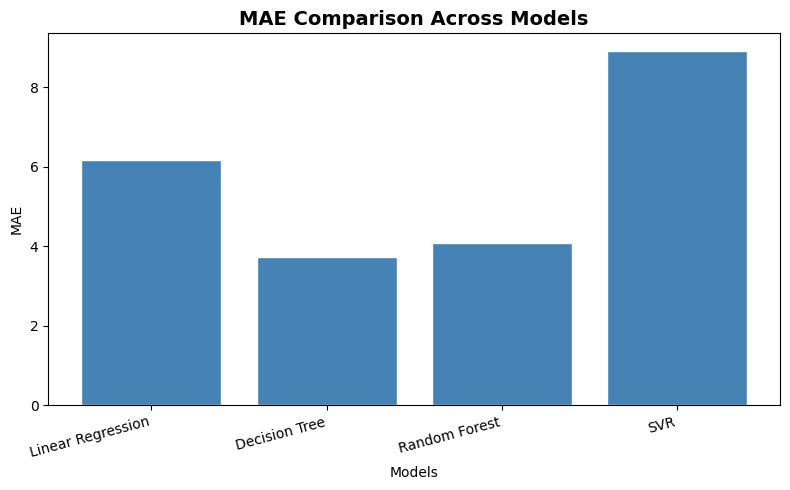

In [19]:
metrics = ['R2', 'RMSE', 'MAE']

for metric in metrics:

    plt.figure(figsize=(8, 5))

    plt.bar(
        results_df['Model'],
        results_df[metric],
        color='steelblue',
        edgecolor='white'
    )

    plt.title(f'{metric} Comparison Across Models',
              fontsize=14,
              fontweight='bold')

    plt.xlabel('Models')
    plt.ylabel(metric)

    plt.xticks(rotation=15, ha='right')

    plt.tight_layout()
    plt.show()

# Actual VS predicted plots for each developed model

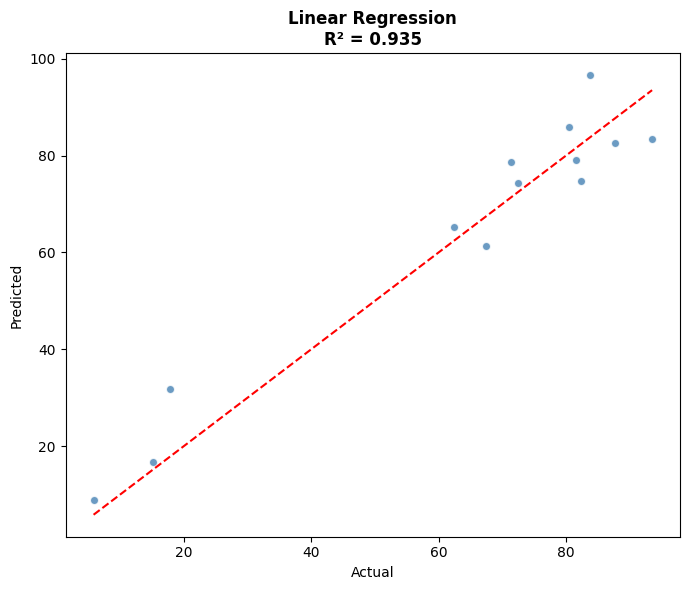

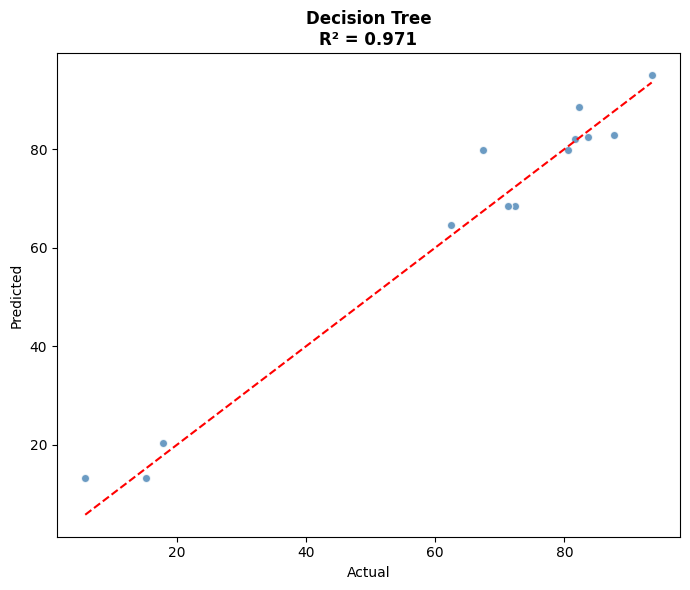

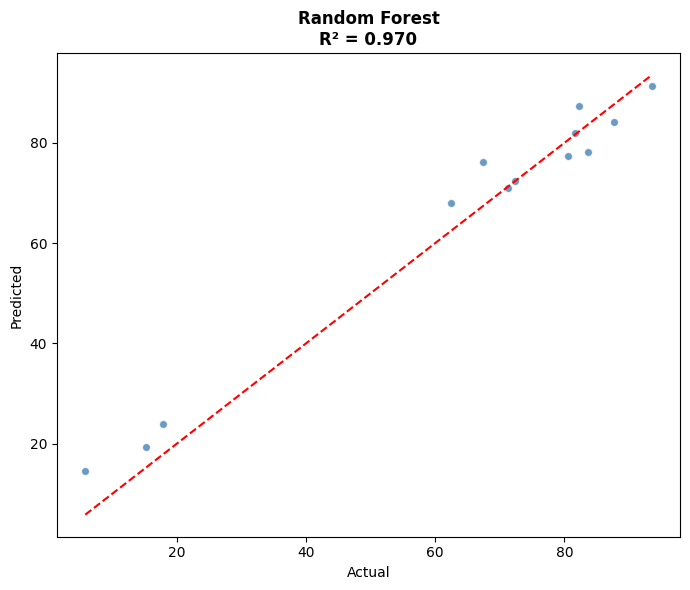

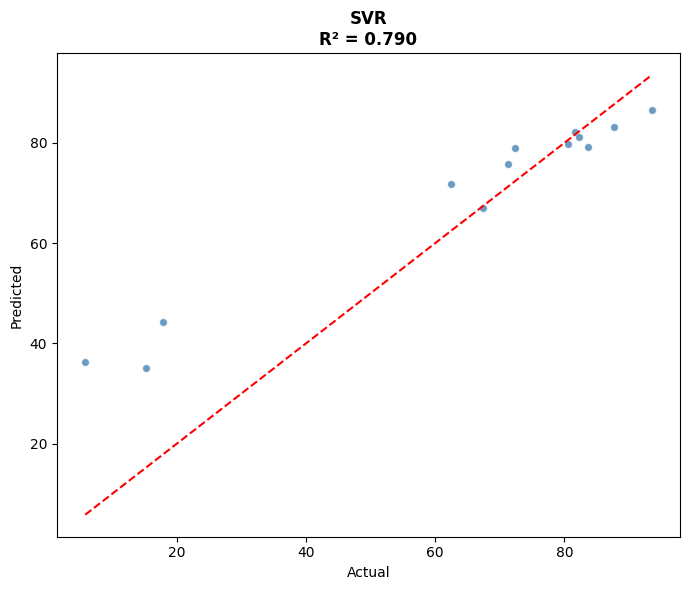

In [20]:
for name, pred in zip(model_names, predictions):

    plt.figure(figsize=(7, 6))

    plt.scatter(
        y_test,
        pred,
        color='steelblue',
        alpha=0.8,
        edgecolors='white'
    )

    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--',
        linewidth=1.5
    )

    plt.xlabel('Actual')
    plt.ylabel('Predicted')

    plt.title(
        f'{name}\nR² = {r2_score(y_test, pred):.3f}',
        fontsize=12,
        fontweight='bold'
    )

    plt.tight_layout()
    plt.show()

# Residual plots

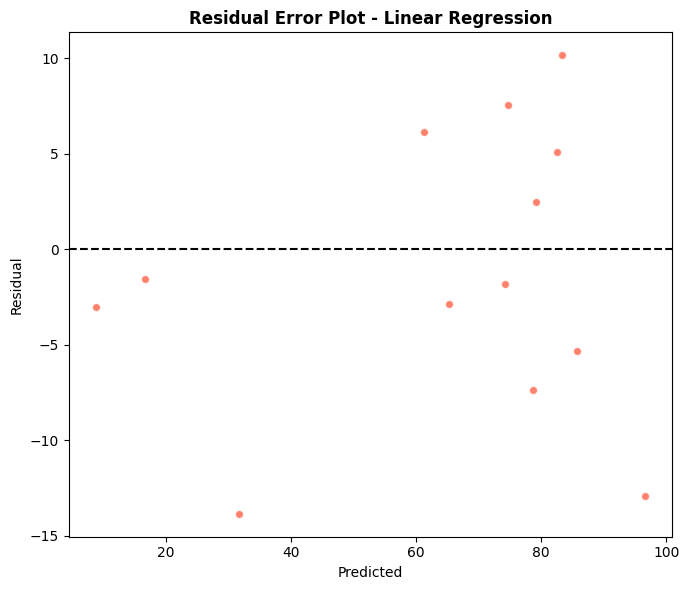

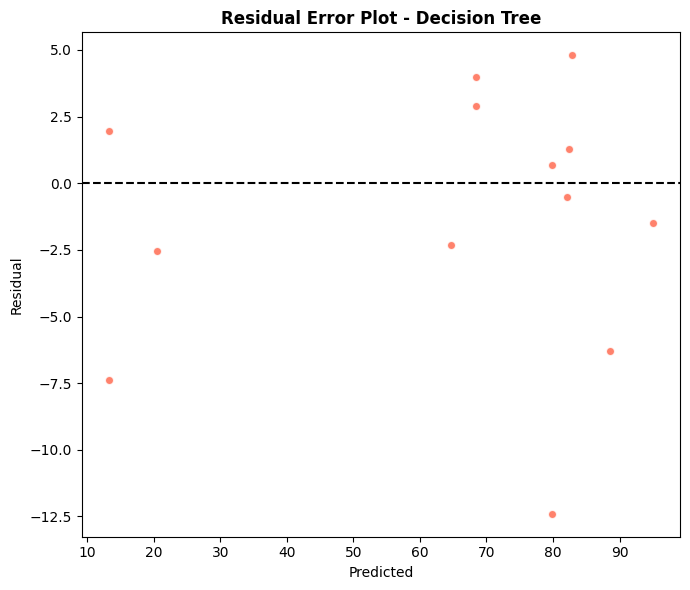

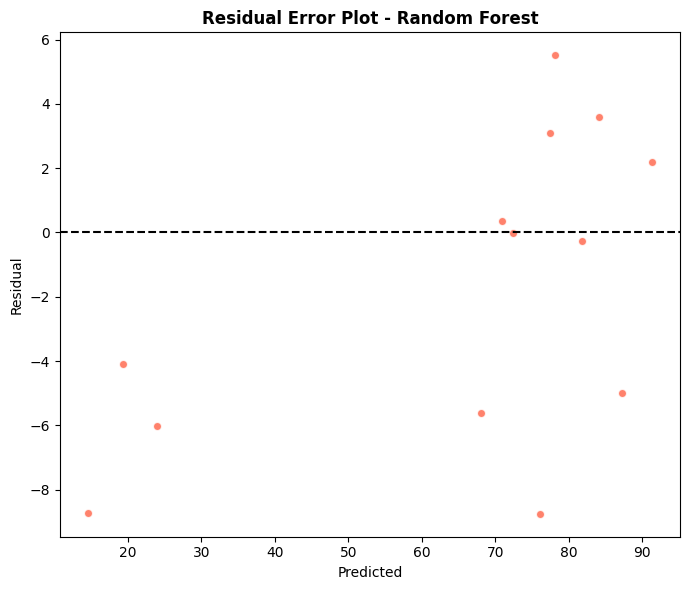

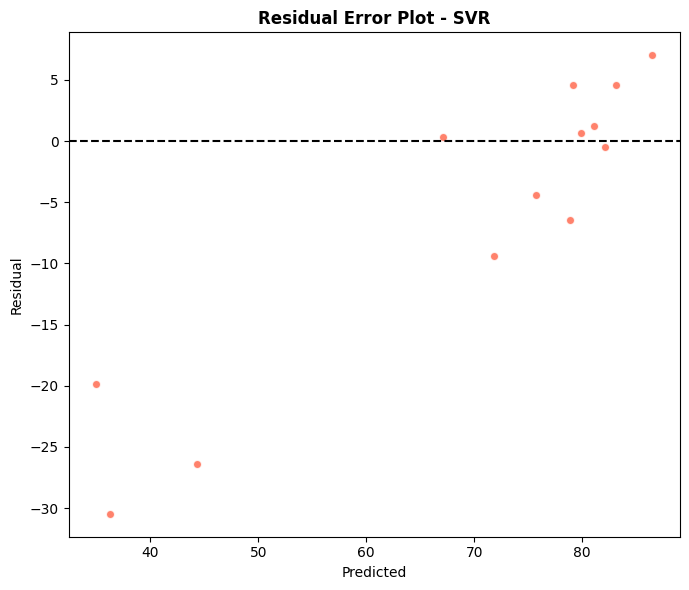

In [21]:
for name, pred in zip(model_names, predictions):

    residuals = y_test.values - pred

    plt.figure(figsize=(7, 6))

    plt.scatter(
        pred,
        residuals,
        color='tomato',
        alpha=0.8,
        edgecolors='white'
    )

    plt.axhline(
        0,
        color='black',
        linestyle='--',
        linewidth=1.5
    )

    plt.xlabel('Predicted')
    plt.ylabel('Residual')

    plt.title(
        f'Residual Error Plot - {name}',
        fontsize=12,
        fontweight='bold'
    )

    plt.tight_layout()
    plt.show()

## FEATURE IMPORTANCE PLOTS ──── SHAP ANALYSIS ─

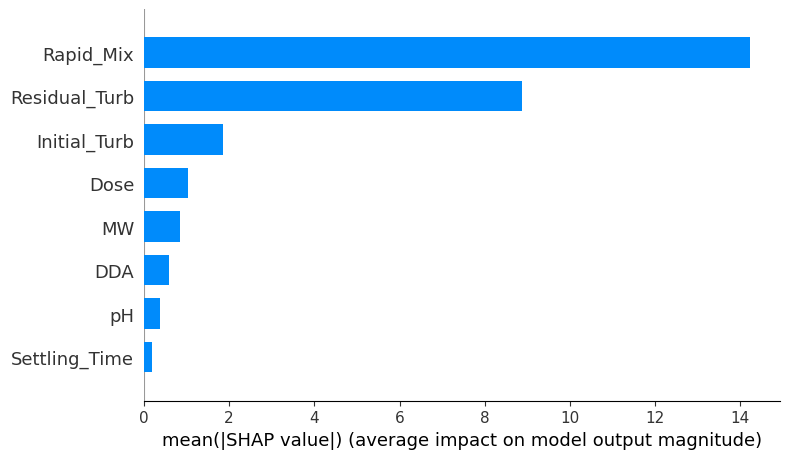

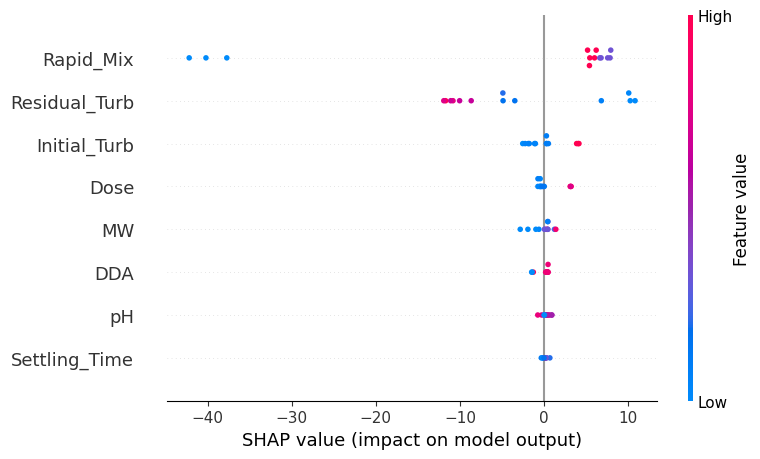

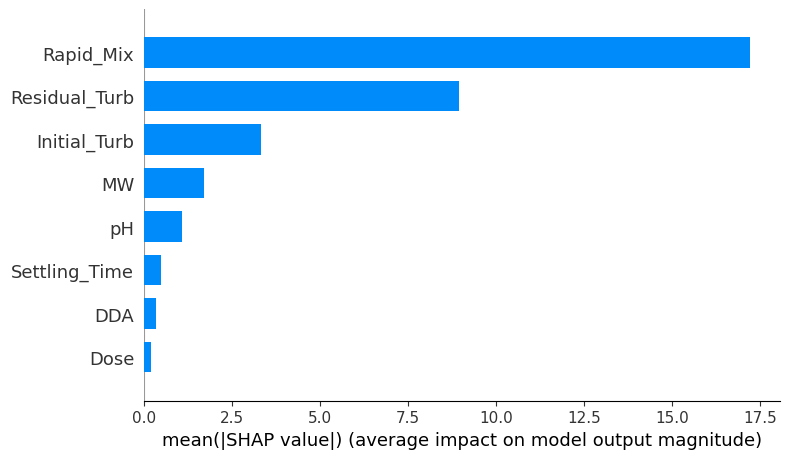

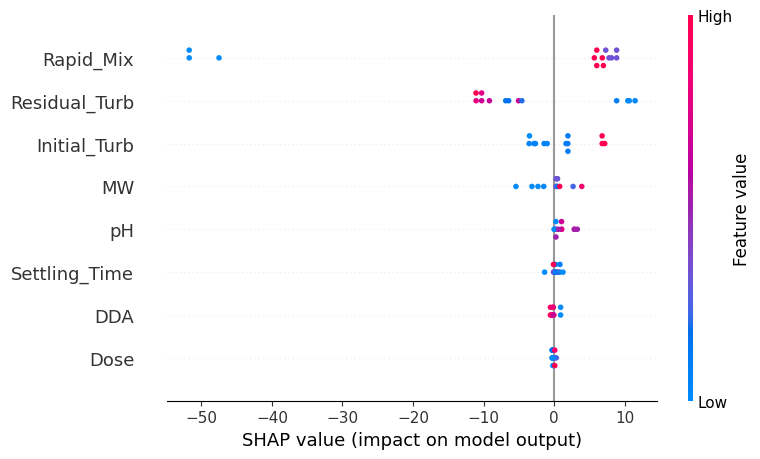

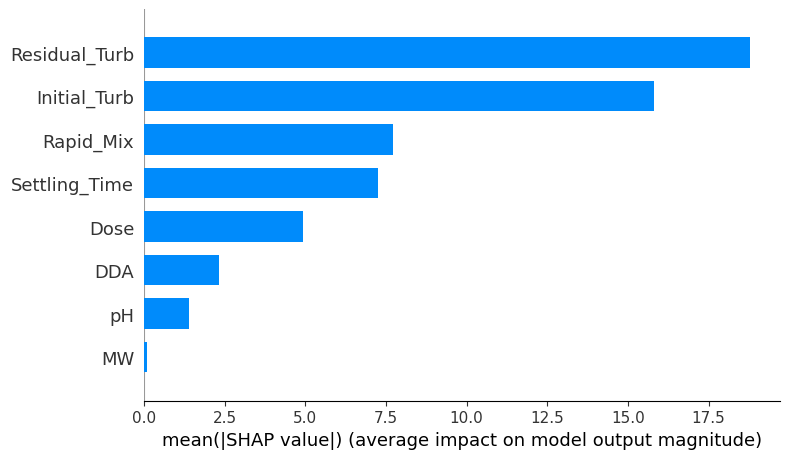

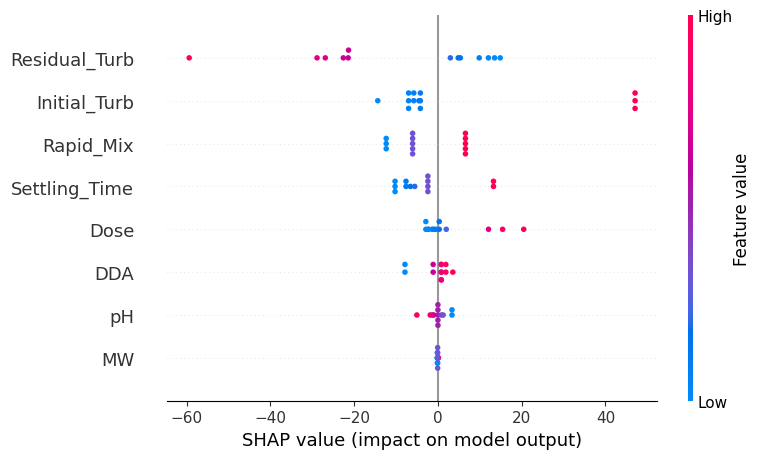

  0%|          | 0/13 [00:00<?, ?it/s]

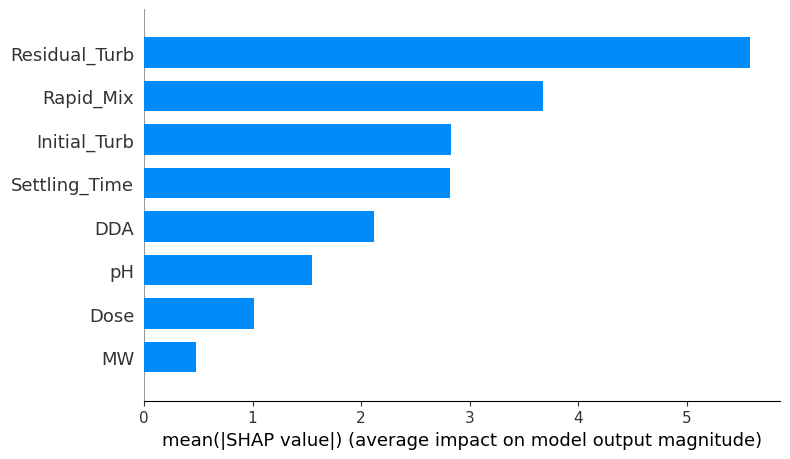

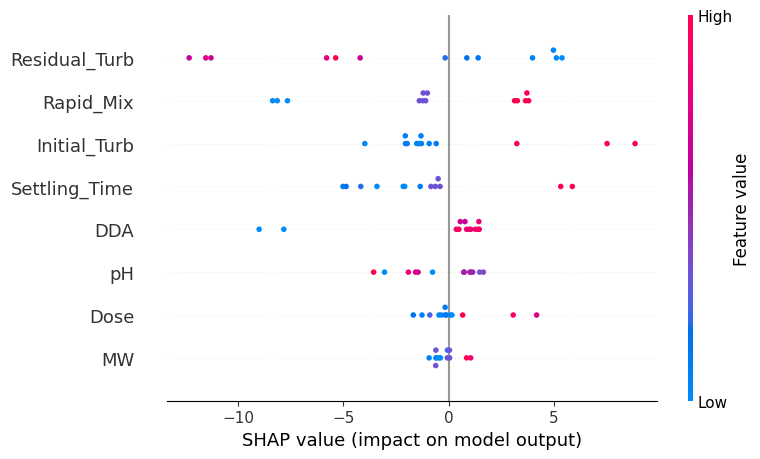

In [22]:
import shap
# Random Forest SHAP
explainer_rf = shap.TreeExplainer(rf)
shap_values_rf = explainer_rf.shap_values(X_test)
shap.summary_plot(shap_values_rf, X_test, feature_names=features, plot_type='bar', show=True)
shap.summary_plot(shap_values_rf, X_test, feature_names=features, show=True)

# Decision Tree SHAP
explainer_dt = shap.TreeExplainer(dt)
shap_values_dt = explainer_dt.shap_values(X_test)
shap.summary_plot(shap_values_dt, X_test, feature_names=features, plot_type='bar', show=True)
shap.summary_plot(shap_values_dt, X_test, feature_names=features, show=True)

# Linear Regression SHAP
explainer_lr = shap.LinearExplainer(lr, X_train_scaled)
shap_values_lr = explainer_lr.shap_values(X_test_scaled)
shap.summary_plot(shap_values_lr, X_test_scaled, feature_names=features, plot_type='bar', show=True)
shap.summary_plot(shap_values_lr, X_test_scaled, feature_names=features, show=True)

# SVR SHAP (KernelExplainer — slower, uses a background sample)
explainer_svr = shap.KernelExplainer(svr.predict, shap.sample(X_train_scaled, 30))
shap_values_svr = explainer_svr.shap_values(X_test_scaled)
shap.summary_plot(shap_values_svr, X_test_scaled, feature_names=features, plot_type='bar', show=True)
shap.summary_plot(shap_values_svr, X_test_scaled, feature_names=features, show=True)

